In [2]:
from google.colab import drive
drive.mount('/content/drive/')
%cd '/content/drive/MyDrive/deep-orderbook-master/'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/MyDrive/deep-orderbook-master


In [3]:
import os
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
#print(os.getcwd())
paths = './coinbase_btc_usd/coinbase/btc_usd/l2_snapshots/100ms/'
#print(os.listdir(paths))
num_files = len([f for f in os.listdir(paths) if os.path.isfile(os.path.join(paths, f))])
print(f"Number of files in the folder: {num_files}")

Number of files in the folder: 216


In [66]:
count = 0
register = {}
day = {}
l2_snapshot = None  # Keep l2_snapshot as a PyTorch tensor on GPU

i = 0
for x in os.listdir(paths):
    path = paths + x
    temp = pd.read_parquet(path)
    # Load the DataFrame to GPU and keep it as a dictionary of tensors
    temp = {col: torch.tensor(temp[col].to_numpy(), device=device, dtype=torch.float32) for col in temp.columns}

    if count%24 == 0:
        day = temp  # Initialize day with temp when count is divisible by 24
    else:
        for col in temp.keys():
            if col in day:
                day[col] = torch.cat((day[col], temp[col]), dim=0)  # Concatenate tensors on GPU
            else:
                day[col] = temp[col]

    i += 1
    count +=1

    if count%24 == 0:
        flag = not register
        # Drop NaNs on GPU (replace NaNs with a placeholder and filter)
        for col in day.keys():
            mask = ~torch.isnan(day[col])  # Keep non-NaN values
            day[col] = day[col][mask]

        #print(day.shape)
        print({col: day[col].shape for col in day.keys()})  # Print shapes of tensors
        result = []

        # Perform calculations (mean, std) on GPU
        for cols, values in day.items():
            mean =values.mean().item()
            std = values.std().item()
            result.append([cols,[mean,std]])

        register[count/24] = result

        if not flag:
            for l in range(200): # Process the first 200 columns
                prev_stat = register[(count/24)-1]
                col_name = prev_stat[l][0]
                col_mean = prev_stat[l][1][0]
                col_std = prev_stat[l][1][1]
                # Normalize on GPU
                if col_name in day:
                    day[col_name] = (day[col_name] - col_mean) / col_std

            # Combine day into l2_snapshot
            if l2_snapshot is None:
                 # Ensure all tensors have at least two dimensions
                l2_snapshot = torch.cat([day[col].unsqueeze(1) if day[col].dim() == 1 else day[col] for col in day.keys()], dim=1)
            else:
                new_snapshot = torch.cat([day[col].unsqueeze(1) if day[col].dim() == 1 else day[col] for col in day.keys()], dim=1)
                l2_snapshot = torch.cat([l2_snapshot, new_snapshot], dim=0)

        # Delete the day data from GPU memory
        del day
        day = {}

    if i>240:
        break

{'b1': torch.Size([435489]), 'b2': torch.Size([435489]), 'b3': torch.Size([435489]), 'b4': torch.Size([435489]), 'b5': torch.Size([435489]), 'b6': torch.Size([435489]), 'b7': torch.Size([435489]), 'b8': torch.Size([435489]), 'b9': torch.Size([435489]), 'b10': torch.Size([435489]), 'b11': torch.Size([435489]), 'b12': torch.Size([435489]), 'b13': torch.Size([435489]), 'b14': torch.Size([435489]), 'b15': torch.Size([435489]), 'b16': torch.Size([435489]), 'b17': torch.Size([435489]), 'b18': torch.Size([435489]), 'b19': torch.Size([435489]), 'b20': torch.Size([435489]), 'b21': torch.Size([435489]), 'b22': torch.Size([435489]), 'b23': torch.Size([435489]), 'b24': torch.Size([435489]), 'b25': torch.Size([435489]), 'b26': torch.Size([435489]), 'b27': torch.Size([435489]), 'b28': torch.Size([435489]), 'b29': torch.Size([435489]), 'b30': torch.Size([435489]), 'b31': torch.Size([435489]), 'b32': torch.Size([435489]), 'b33': torch.Size([435489]), 'b34': torch.Size([435489]), 'b35': torch.Size([435

In [67]:
# Define the column names and their indices in the tensor
column_names = ['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'b10',
                'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'a10',
                'bq1', 'bq2', 'bq3', 'bq4', 'bq5', 'bq6', 'bq7', 'bq8', 'bq9', 'bq10',
                'aq1', 'aq2', 'aq3', 'aq4', 'aq5', 'aq6', 'aq7', 'aq8', 'aq9', 'aq10']
# Assume these column names map to specific indices in the tensor
# Update this list with the corresponding column indices (0-based indexing)
column_indices = list(range(len(column_names)))

# Use indexing to select the desired columns from the tensor
l2_snapshot_ = l2_snapshot[:, column_indices]  # Select columns along the second dimension (dim=1)

# Verify the resulting tensor
print(f"Shape of l2_snapshot_: {l2_snapshot_.shape}")

Shape of l2_snapshot_: torch.Size([4403658, 40])


In [68]:
def generate_features_labels(df, ask, bid, k=20, alpha = 10e-5):
    # Move required columns to GPU
    #print(df[ask].dtype)
    # Extract ask and bid columns using indices, as l2_snapshot is a tensor
    ask_tensor = df[:, ask]  # Use numerical indexing for the ask column
    bid_tensor = df[:, bid]  # Use numerical indexing for the bid column

    # Compute mid_price and initialize target on GPU
    mid_price = (ask_tensor + bid_tensor) / 2
    target = torch.ones(mid_price.shape[0], device="cuda", dtype=torch.int32)

    shape = mid_price.shape[0]

    # Precompute initial means for m_b and m_a
    m_b = mid_price[:k].mean()
    m_a = mid_price[k+1:2*k+1].mean()
    val = mid_price[0]
    valB = mid_price[k+1]

    # Start the target calculation
    for i in tqdm(range(k, shape - k)):
        if i != k:
            # Update m_b and m_a incrementally
            curr_val = mid_price[i - 1]
            curr_valB = mid_price[i + k]
            m_b = (m_b * k + curr_val - val) / k
            m_a = (m_a * k + curr_valB - valB) / k
            val = mid_price[i - k]
            valB = mid_price[i + 1]

        # Update target using GPU-based operations
        if (m_b > m_a * (1 + alpha)):
            target[i] = 2
        if (m_b < m_a * (1 - alpha)):
            target[i] = 0

    # Slice the target and prepare features
    target = target[k:shape - k]  # Keep the relevant range of target
    features = df[k:shape - k, :].clone().detach().to(device="cuda", dtype=torch.float32)
    return features, target

In [69]:
print(type(l2_snapshot))
print(l2_snapshot.shape)
print(l2_snapshot[:, 1].dtype)

<class 'torch.Tensor'>
torch.Size([4403658, 200])
torch.float32


Bypass the following 2 cells since all data have been treated and save in "X_data.csv" and "y_data.csv"

In [ ]:
# GridSearch
min_ = float('inf')
minI = 0

# Iterate over logarithmic values using PyTorch tensors
for i in torch.logspace(0, -8, steps=10, device="cuda"):  # Perform logspace directly on the GPU
    # Generate features and labels on the GPU
    X, y = generate_features_labels(l2_snapshot, ask=1, bid=1, alpha=i.item())

    # Convert labels to GPU tensor and calculate class counts
    y_ = y.clone().detach().to(device="cuda")
    temp = torch.bincount(y_)  # Equivalent to value_counts, works for categorical data

    # Handle cases where some categories may be missing
    if temp.size(0) < 3:  # Ensure all categories (0, 1, 2) are represented
        temp = torch.cat([temp, torch.zeros(3 - temp.size(0), device="cuda")])

    a, b, c = temp[0].item(), temp[1].item(), temp[2].item()  # Convert counts back to Python integers
    sum_ = a + b + c

    # Calculate l2 using GPU tensors
    l2 = ((1 / 3 - (a / sum_)) * 100) ** 2 + ((1 / 3  -(b / sum_)) * 100) ** 2 + ((1 / 3-(c / sum_)) * 100) ** 2

    # Update minimum l2 and corresponding alpha value
    if l2 < min_:
        min_ = l2
        minI = i.item()  # Use the alpha value

    # Clear GPU memory for variables not needed anymore
    del X, y, temp

print(f"Optimal alpha: {minI}, Minimum l2: {min_}")

100%|██████████| 4403618/4403618 [12:20<00:00, 5948.65it/s]

Optimal alpha: 9.99999993922529e-09, Minimum l2: 12.552750812533187


In [ ]:
minI = 9.99999993922529e-09
min_ = 12.552750812533187

X, y = generate_features_labels(l2_snapshot_, ask=1, bid=1, alpha=minI)
# Convert X and y into DataFrames
X_df = pd.DataFrame(X)
y_df = pd.DataFrame(y, columns=["label"])  # Naming the label column
# Write to CSV files
X_df.to_csv("X_data.csv", index=False)
y_df.to_csv("y_data.csv", index=False)

print("Data successfully written to CSV files.")

100%|██████████| 4403618/4403618 [12:18<00:00, 5959.49it/s]


In [6]:
import pandas as pd
import torch

# Read CSV files into DataFrames
X_df = pd.read_csv("X_data.csv")
y_df = pd.read_csv("y_data.csv")

# Convert DataFrames to PyTorch tensors
X = torch.tensor(X_df.values, dtype=torch.float32)  # Ensure correct dtype
y = torch.tensor(y_df["label"].values, dtype=torch.long)  # Labels should be integers

del X_df, y_df
print("Shapes:", X.shape, y.shape)

Shapes: torch.Size([4403618, 40]) torch.Size([4403618])


<Axes: ylabel='count'>

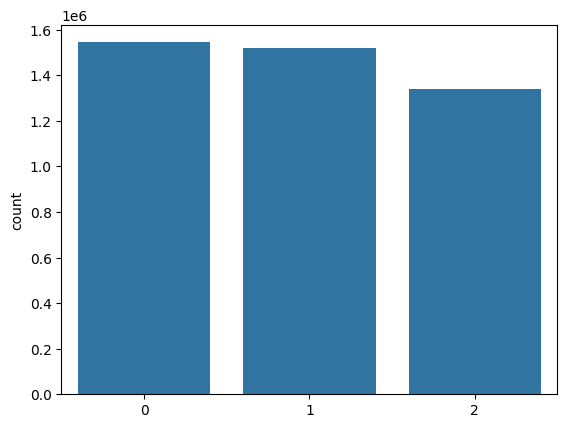

In [71]:
#y = y.to(dtype=torch.int)
# Move tensor to CPU and convert to NumPy
y_cpu = y.cpu().numpy()
sns.countplot(x = y_cpu)

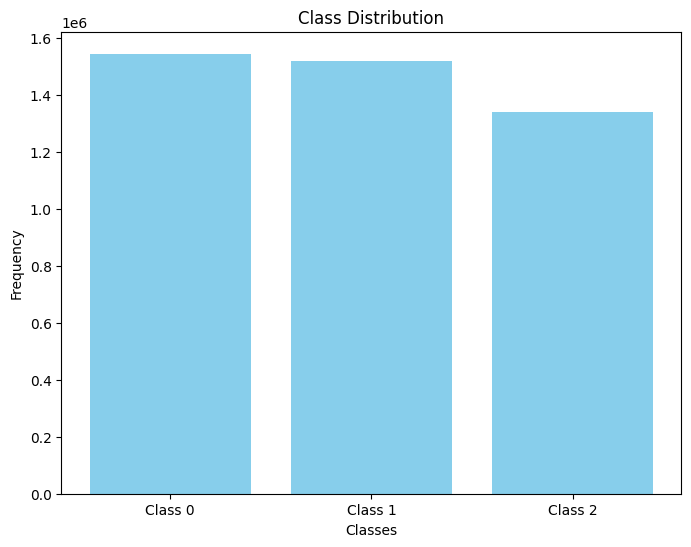

In [72]:
# Move tensor to CPU and compute class counts
#y_cpu = y.cpu()  # Transfer tensor to CPU
counts = torch.bincount(y_cpu)  # Compute counts for each class

# Plot counts using Matplotlib
plt.figure(figsize=(8, 6))
plt.bar(range(len(counts)), counts.numpy(), color='skyblue')  # Create bar plot
plt.xticks(range(len(counts)), labels=[f'Class {i}' for i in range(len(counts))])  # Label classes
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Frequency")
plt.show()

In [7]:
T = 100
D = 40
#trainPart = 3176046

percent = 0.4 #0.2 #0.1  # RAM restriction, use 10% of data
N = round(percent * len(X)) - T # RAM restriction, use 10% of data
trainPart = round(0.8 * N)
print("N=", N, " trainPart=", trainPart)

N= 1761347  trainPart= 1409078


In [ ]:
#N = len(X) - T
#trainPart = 317604 #3176046 # RAM restriction, use 10% of data


In [8]:
X_train = torch.zeros((trainPart, T, D), dtype=torch.float32)
y_train = torch.zeros(trainPart, dtype=torch.long)

#Preparing the time series data using timestep of 100 and no of features = 200
for t in range(trainPart):
    X_train[t, :, :] = X[t:t+T].to(dtype=torch.float32)
    y_train[t] = y[t+T].to(dtype=torch.long)

print('X_train - Before: {} GB'.format(X_train.nbytes/1024**3), X_train.dtype)
print(X.shape)
print('y_train - Before: {} GB'.format(y_train.nbytes/1024**3), y_train.dtype)
print(y.shape)

X_train - Before: 20.996898412704468 GB torch.float32
torch.Size([4403618, 40])
y_train - Before: 0.010498449206352234 GB torch.int64
torch.Size([4403618])


In [9]:
X_test = torch.zeros((N - trainPart, T, D), dtype=torch.float32)
y_test = torch.zeros(N - trainPart, dtype=torch.long)

#Preparing the time series data using timestep of 100 and no of features = 40
for k in range(N - trainPart):
    t = k + trainPart
    X_test[k, :, :] = X[t:t+T]
    y_test[k] = y[t+T]

print('X_test - Before: {} GB'.format(X_test.nbytes/1024**3), X_test.dtype)
print('y_test - Before: {} GB'.format(y_test.nbytes/1024**3), y_test.dtype)

X_test - Before: 5.24921715259552 GB torch.float32
y_test - Before: 0.00262460857629776 GB torch.int64


In [98]:
# prompt: write X_train, y_train, X_test, y_test into csv files

import numpy as np
import pandas as pd

# Convert tensors to numpy arrays before saving to CSV
X_train_np = X_train.numpy()
y_train_np = y_train.numpy()
X_test_np = X_test.numpy()
y_test_np = y_test.numpy()

# Create pandas DataFrames
X_train_df = pd.DataFrame(X_train_np.reshape(X_train_np.shape[0], -1)) # Reshape for CSV compatibility
y_train_df = pd.DataFrame(y_train_np, columns=['label'])
X_test_df = pd.DataFrame(X_test_np.reshape(X_test_np.shape[0], -1)) # Reshape for CSV compatibility
y_test_df = pd.DataFrame(y_test_np, columns=['label'])

# Save DataFrames to CSV files
X_train_df.to_csv('X_train.csv', index=False)
y_train_df.to_csv('y_train.csv', index=False)
X_test_df.to_csv('X_test.csv', index=False)
y_test_df.to_csv('y_test.csv', index=False)

print("Data successfully written to CSV files.")

Data successfully written to CSV files.


In [ ]:
# input the saved data
import pandas as pd
import torch

# Read CSV files into DataFrames
X_df = pd.read_csv("X_train.csv")
y_df = pd.read_csv("y_train.csv")

# Convert DataFrames to PyTorch tensors
X_train = torch.tensor(X_df.values, dtype=torch.float32)  # Ensure correct dtype
X_train = X_train.view(trainPart, T, D)
y_train = torch.tensor(y_df["label"].values, dtype=torch.long)  # Labels should be integers

# Read CSV files into DataFrames
X_df = pd.read_csv("X_test.csv")
y_df = pd.read_csv("y_test.csv")

# Convert DataFrames to PyTorch tensors
X_test = torch.tensor(X_df.values, dtype=torch.float32)  # Ensure correct dtype
X_test = X_test.view(N - trainPart, T, D)
y_test = torch.tensor(y_df["label"].values, dtype=torch.long)  # Labels should be integers

del X_df, y_df
print("Shapes:", X_train.shape, y_train.shape)
print("Shapes:", X_test.shape, y_test.shape)

In [10]:
from torch.utils.data import TensorDataset, DataLoader
# Create a TensorDataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
del X_train, y_train #, X_test, y_test


In [105]:
pip install torchinfo

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_RNN_Classifier(nn.Module):
    '''
    Keras model:
    Conv2D → Reshape → Conv1D → MaxPool1D → Conv1D → MaxPool1D → BiLSTM → Dense → Dense → Output
    Input: (batch_size, 100, 40, 1)
    '''

    def __init__(self, input_shape, T, D):
        super(CNN_RNN_Classifier, self).__init__()
        # First Conv2D layer, input (B, 1, 100, 40) -> output (B, 16, 97, 1)
        self.conv2d = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=(4, D))
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)
        # Reshape layer (to reshape for Conv1D)
        self.T = T  # Store T for dynamic reshaping
        # First Conv1D layer
        self.conv1d_1 = nn.Conv1d(in_channels=16, out_channels=16, kernel_size=4)
        # Batch Normalization
        self.bn1 = nn.BatchNorm1d(16, momentum=0.1)
        # MaxPooling1D
        self.maxpool1 = nn.MaxPool1d(kernel_size=2)
        # Second Conv1D layer
        self.conv1d_2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3)
        # Batch Normalization
        self.bn2 = nn.BatchNorm1d(32, momentum=0.1)
        # MaxPooling1D
        self.maxpool2 = nn.MaxPool1d(kernel_size=2)
        # Bidirectional LSTM
        self.lstm = nn.LSTM(input_size=22, hidden_size=64, bidirectional=True, batch_first=True)
        # Dense layers
        self.fc1 = nn.Linear(64 * 2, 32)  # *2 because it's bidirectional
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 3)  # 3 output classes for softmax

    def forward(self, x):
        # Conv2D
        x = self.conv2d(x)
        x = self.leaky_relu(x)
        # Reshape from Conv2D output to match Conv1D input
        x = x.view(x.shape[0], 16, -1)
        # First Conv1D
        x = self.conv1d_1(x)
        # Batch Normalization + MaxPooling
        x = self.bn1(x)
        x = self.leaky_relu(x)
        # Batch Normalization + MaxPooling
        #x = self.bn1(x)
        x = self.maxpool1(x)
        # Second Conv1D
        x = self.conv1d_2(x)
        x = self.leaky_relu(x)
        # Batch Normalization + MaxPooling
        x = self.bn2(x)
        x = self.maxpool2(x)
        # Check the shape before LSTM
        #print("Shape before LSTM:", x.shape) # Print the shape before entering LSTM
        # Bidirectional LSTM
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Last time step
        # Dense layers
        x = self.fc1(x)
        x = self.leaky_relu(x)
        x = self.fc2(x)
        x = self.leaky_relu(x)
        x = self.fc3(x)
        # Softmax output
        #x = F.softmax(x, dim=-1)
        return x

In [112]:
from torchinfo import summary
input_size = (32, 1, 100, 40)  # (batch_size, channels, height, width)
summary(CNN_RNN_Classifier(input_shape=(32, T, D), T=100, D=40), input_size=input_size)

Layer (type:depth-idx)                   Output Shape              Param #
CNN_RNN_Classifier                       [32, 3]                   --
├─Conv2d: 1-1                            [32, 16, 97, 1]           2,576
├─LeakyReLU: 1-2                         [32, 16, 97, 1]           --
├─Conv1d: 1-3                            [32, 16, 94]              1,040
├─BatchNorm1d: 1-4                       [32, 16, 94]              32
├─LeakyReLU: 1-5                         [32, 16, 94]              --
├─MaxPool1d: 1-6                         [32, 16, 47]              --
├─Conv1d: 1-7                            [32, 32, 45]              1,568
├─LeakyReLU: 1-8                         [32, 32, 45]              --
├─BatchNorm1d: 1-9                       [32, 32, 45]              64
├─MaxPool1d: 1-10                        [32, 32, 22]              --
├─LSTM: 1-11                             [32, 32, 128]             45,056
├─Linear: 1-12                           [32, 32]                  4,128

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math
from torch.amp import autocast

# Hyperparameters
epochs = 40 #10
batch_size = 32 #128 #32
learning_rate = 0.001 #0.00001 0.0001 #0.001

# Create TensorDataset
#train_dataset = TensorDataset(X_train, y_train)
#test_dataset = TensorDataset(X_test, y_test)
# Create DataLoader for batching
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

# define model
model = CNN_RNN_Classifier(input_shape=(batch_size, T, D), T=T, D=D).to(device)  # Move model to GPU if available
# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # Use Adam optimizer
# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define accuracy calculation (PyTorch doesn't include it natively)
def calculate_accuracy(y_pred, y_true):
    y_pred_classes = torch.argmax(y_pred, dim=1)  # Get class predictions
    y_true = y_true.to(y_pred_classes.device)
    correct = (y_pred_classes == y_true).sum().item()
    accuracy = correct / y_true.size(0)
    return accuracy
#
#
##### Training Loop #####
for epoch in range(epochs):
    ### train model ###
    model.train()
    epoch_loss, epoch_acc = 0, 0
    total_samples = 0
    # k = 0
    # generate a batch of training data, each training data contain T*D values
    for X_batch, y_batch in train_loader:
        # Forward pass
        optimizer.zero_grad()
        X_batch = X_batch.view(X_batch.size(0), 1, T, D)  # Add channel dimension
        outputs = model(X_batch.to(device))
        loss = criterion(outputs, y_batch.to(device))
        # Backward pass
        loss.backward()
        optimizer.step()
        # Accumulate metrics
        total_samples += y_batch.size(0)
        epoch_loss += loss.item()
        # epoch_acc += calculate_accuracy(outputs, y_batch)
        epoch_acc += calculate_accuracy(outputs, y_batch) * y_batch.size(0)  # Weighted accuracy
        # k += 1
    #
    # Average over all batches
    epoch_loss /= len(train_loader)
    # epoch_acc /= len(train_loader)
    epoch_acc /= total_samples  # Compute final train accuracy

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.4f}")

    ### test model ###
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.no_grad():  # Disable gradient computation during evaluation
        for X_batch, y_batch in test_loader:
            # Forward pass
            X_batch = X_batch.view(X_batch.size(0), 1, T, D)  # Add channel dimension
            outputs = model(X_batch.to(device))
            loss = criterion(outputs, y_batch.to(device))
            # Accumulate metrics
            test_loss += loss.item()
            test_acc += calculate_accuracy(outputs, y_batch)

        # Average metrics over batches
        test_loss /= len(test_loader)
        test_acc /= len(test_loader)

    print(f"            Test  Loss: {test_loss:.4f}, Test  Accuracy: {test_acc:.4f}")

Epoch 1/40, Train Loss: 1.0934, Train Accuracy: 0.3695
            Test  Loss: 1.1113, Test  Accuracy: 0.3557
Epoch 2/40, Train Loss: 1.0868, Train Accuracy: 0.3852
            Test  Loss: 1.0783, Test  Accuracy: 0.4031
Epoch 3/40, Train Loss: 1.0334, Train Accuracy: 0.4614
            Test  Loss: 1.0355, Test  Accuracy: 0.4726
Epoch 4/40, Train Loss: 0.9755, Train Accuracy: 0.5141
            Test  Loss: 1.0255, Test  Accuracy: 0.5050
Epoch 5/40, Train Loss: 0.8825, Train Accuracy: 0.5829
            Test  Loss: 0.8610, Test  Accuracy: 0.6012
Epoch 6/40, Train Loss: 0.8391, Train Accuracy: 0.6065
            Test  Loss: 0.8146, Test  Accuracy: 0.6296
Epoch 7/40, Train Loss: 0.8181, Train Accuracy: 0.6193
            Test  Loss: 0.8201, Test  Accuracy: 0.6217
Epoch 8/40, Train Loss: 0.7985, Train Accuracy: 0.6321
            Test  Loss: 0.8305, Test  Accuracy: 0.6278
Epoch 9/40, Train Loss: 0.7842, Train Accuracy: 0.6406
            Test  Loss: 0.7810, Test  Accuracy: 0.6500
Epoch 10/4

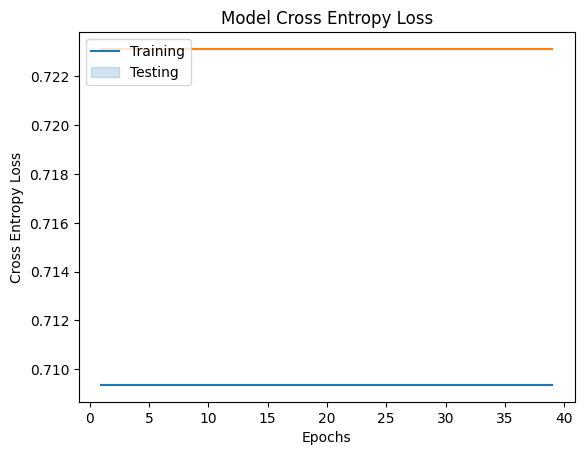

In [17]:
sns.lineplot(x=range(1, epoch + 1), y=epoch_loss)
sns.lineplot(x=range(1, epoch + 1), y=test_loss)
plt.title('Model Cross Entropy Loss')
plt.ylabel('Cross Entropy Loss')
plt.xlabel('Epochs')
plt.legend(['Training', 'Testing'], loc='upper left')

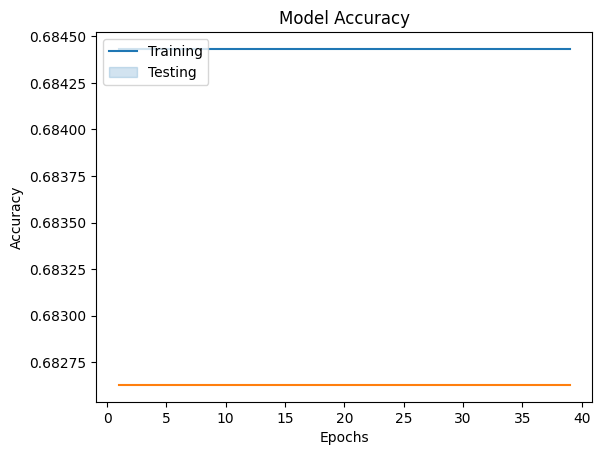

In [18]:
sns.lineplot(x=range(1, epoch + 1), y=epoch_acc)
sns.lineplot(x=range(1, epoch + 1), y=test_acc)
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Training', 'Testing'], loc='upper left')

In [19]:
# Ensure the model is in evaluation mode
model.eval()
print(device)
selected_indices = torch.randperm(X_test.shape[0], device=device)[:int(0.01 * X_test.shape[0])]
X_pred = X_test.to(device)[selected_indices]
y_true = y_test.to(device)[selected_indices]

X_pred = X_pred.to(device)
y_true = y_true.to(device)

# Reshape X_pred to match the expected input shape
X_pred = X_pred.view(X_pred.size(0), 1, T, D) # Reshape before passing to model

# Perform a forward pass
with torch.no_grad():  # Disable gradient computation
    y_pred_logits = model(X_pred)  # Get raw scores (logits)

# Get class predictions using argmax
y_pred = torch.argmax(y_pred_logits, dim=1).cpu().numpy()  # Convert to NumPy array if needed

# Print predictions
print(y_pred)

cuda
[2 0 0 ... 1 2 0]


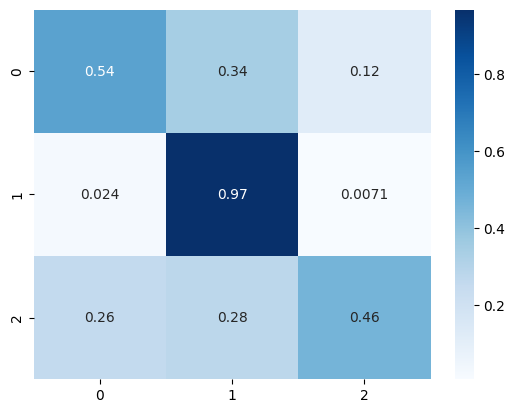

In [20]:
from sklearn.metrics import confusion_matrix

y_true_cpu = y_true.cpu().numpy()
#y_pred_cpu = y_pred.cpu().numpy()
cm = confusion_matrix(y_pred=y_pred, y_true=y_true_cpu)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ax=sns.heatmap(cm, annot=True, xticklabels=[0,1,2], yticklabels=[0,1,2], cmap='Blues')
ax.set_ylim(3.0, 0)
plt.show()

In [127]:
print(classification_report(y_true_cpu, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.50      0.60       713
           1       0.45      0.94      0.60       445
           2       0.78      0.43      0.56       603

    accuracy                           0.59      1761
   macro avg       0.66      0.63      0.59      1761
weighted avg       0.68      0.59      0.59      1761

